In [381]:
def border_line(length=64):
    print("=-" * int(length / 2), end="=\n")


open_bold = "\033[1m"
close_bold = "\033[0m"

indentation = "    "

In [382]:
border_line(58)
print("Análise de anúncios de aluguel de imóveis de curta duração.")
border_line(58)
print("\nA base de dados é um CSV de 17 colunas e 12'044 entradas.\n")
print(
    "Os campos textuais em algumas entradas não trataram devidamente as vírgulas, o que separou uma coluna em múltiplas."
)
print("Os dados foram importados no LibreOffice para encontrar essas distorções.\n")
print('Coluna "Nome do anúncio": 8 distorções.')
print(
    'As linhas foram ordenadas pela coluna seguinte, "ID do anunciante". Aquelas com valores textuais ficaram ao final.\n'
)

print('Coluna "Licença": 6 distorções.')
print(
    "Como é a última coluna esperada, qualquer dado que se apresentava após si foi identificado."
)

=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
Análise de anúncios de aluguel de imóveis de curta duração.
=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=

A base de dados é um CSV de 17 colunas e 12'044 entradas.

Os campos textuais em algumas entradas não trataram devidamente as vírgulas, o que separou uma coluna em múltiplas.
Os dados foram importados no LibreOffice para encontrar essas distorções.

Coluna "Nome do anúncio": 8 distorções.
As linhas foram ordenadas pela coluna seguinte, "ID do anunciante". Aquelas com valores textuais ficaram ao final.

Coluna "Licença": 6 distorções.
Como é a última coluna esperada, qualquer dado que se apresentava após si foi identificado.


In [383]:
import textwrap
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def print_numerical_range(
    series: pd.Series,
):
    min_value, max_value = series.min(), series.max()
    if hasattr(min_value, "strftime") and hasattr(max_value, "strftime"):
        min_text = min_value.strftime("%Y-%m-%d")
        max_text = max_value.strftime("%Y-%m-%d")
    else:
        min_text = str(min_value)
        max_text = str(max_value)
    text = f"Intervalo numérico: [{min_text}, {max_text}]"
    print(textwrap.indent(text, indentation))


def column_description(
    name: str,
    series: pd.Series,
    type_description: str,
    description: str,
    column_type: Literal["categorical", "numerical", "date", "other"] = "other",
):
    print(f"{open_bold}{name}{close_bold}")

    empty_amount = series.isnull().sum()
    total_amount = series.count()
    text = f"Identificador: {series.name}\nTipo: {type_description}\n{description}\nVazios: {empty_amount} de {total_amount} ({(empty_amount / total_amount):.2%})"
    print(
        textwrap.indent(
            text,
            indentation,
        )
    )

    if column_type == "categorical":
        values = sorted(series.dropna().unique().tolist())
        text = f"Valores possíveis: {len(values)} {values!s}"
        print(textwrap.indent(text, indentation))

    elif column_type == "date":
        print_numerical_range(series)

    elif column_type == "numerical":
        print_numerical_range(series)
        text = f"Média: {series.mean()}\nMediana: {series.median()}\nDesvio padrão: {series.std()}\nPercentil 05%: {series.quantile(0.05)}\nPercentil 25%: {series.quantile(0.25)}\nPercentil 50%: {series.quantile(0.5)}\nPercentil 75%: {series.quantile(0.75)}\nPercentil 95%: {series.quantile(0.95)}"
        print(textwrap.indent(text, indentation))
        plt.boxplot(series.dropna())
        plt.xlabel("Boxplot")
        plt.ylabel(name)
        plt.show()


In [384]:
def generate_histogram(series: pd.Series, label: str, bins: int | None = None):
    plt.figure(figsize=(10, 5))
    plt.ylabel("Quantidade")
    plt.xlabel(label)
    plt.hist(
        series.dropna(),
        bins=bins,
    )
    plt.show()


def generate_bar_graph(series: pd.Series, label: str):
    counts = series.value_counts()
    fig, ax = plt.subplots(figsize=(10, 5))
    x = range(len(counts))
    ax.bar(x, counts.values)
    ax.set_xticks(x)
    ax.set_xticklabels(
        counts.index,
        rotation=45,
        ha="right",
    )
    ax.set_xlabel(label)
    ax.set_ylabel("Quantidade")
    fig.tight_layout()
    plt.show()


def generate_pie_graph_with_others(
    series: pd.Series,
    label: str,
    top_n: int = 9,
):
    counts = series.value_counts()
    if len(counts) > top_n:
        top = counts.iloc[:top_n]
        others = counts.iloc[top_n:].sum()
        counts = pd.concat(
            [
                top,
                pd.Series({"Outros": others}),
            ]
        )
    _fig, ax = plt.subplots(figsize=(10, 7))
    ax.pie(
        counts,
        labels=counts.index,
        autopct="%1.1f%%",
        startangle=90,
    )
    ax.set_title(f"Distribuição por {label}")
    plt.tight_layout()
    plt.show()

In [385]:
df = pd.read_csv("data/1_Porto.csv")
df["last_review"] = pd.to_datetime(
    df["last_review"], errors="coerce", format="%Y-%m-%d"
)

In [386]:
from categorical import neighborhoods, neighbourhood_groups, room_types

df.neighbourhood_group = pd.Categorical(
    df.neighbourhood_group,
    categories=neighbourhood_groups,
    ordered=False,
)

df.neighbourhood = pd.Categorical(
    df.neighbourhood,
    categories=neighborhoods,
    ordered=False,
)

df.room_type = pd.Categorical(
    df.room_type,
    categories=room_types,
    ordered=False,
)

=-=-=-=
Colunas
=-=-=-=

ID do anúncio
    Identificador: id
    Tipo: Textual (sequência de dígitos)
    Identificador interno dado pelo Airbnb para esta entrada.
    Vazios: 0 de 12044 (0.00%)

Nome do anúncio
    Identificador: name
    Tipo: Textual
    Nome dado pelos anunciantes a este anúncio.
    Vazios: 0 de 12044 (0.00%)

ID do anunciante
    Identificador: host_id
    Tipo: Textual (sequência de dígitos)
    Identificador interno dado pelo Airbnb para a conta do anunciante que registrou esta entrada.
    Vazios: 0 de 12044 (0.00%)

Nome do anunciante
    Identificador: host_name
    Tipo: Textual
    Nome do anunciante que registrou esta entrada. Mesmo quando há mais de uma pessoa, eles são responsáveis pela mesma conta no Airbnb.
    Vazios: 0 de 12044 (0.00%)

Município do imóvel
    Identificador: neighbourhood_group
    Tipo: Categórico, não ordenado
    Município em que o imóvel anunciado está localizado. Obtido por meio da localização geográfica.
    Vazios: 0 de 12044

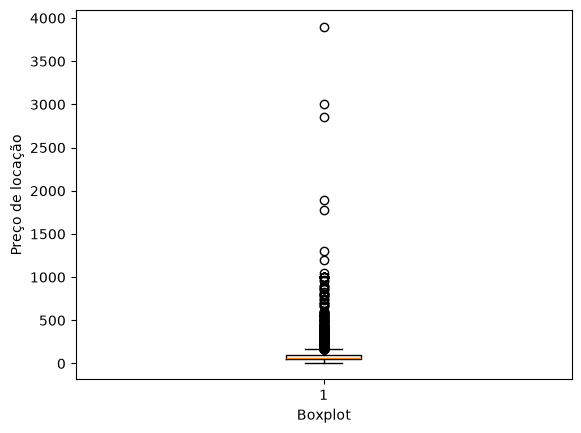

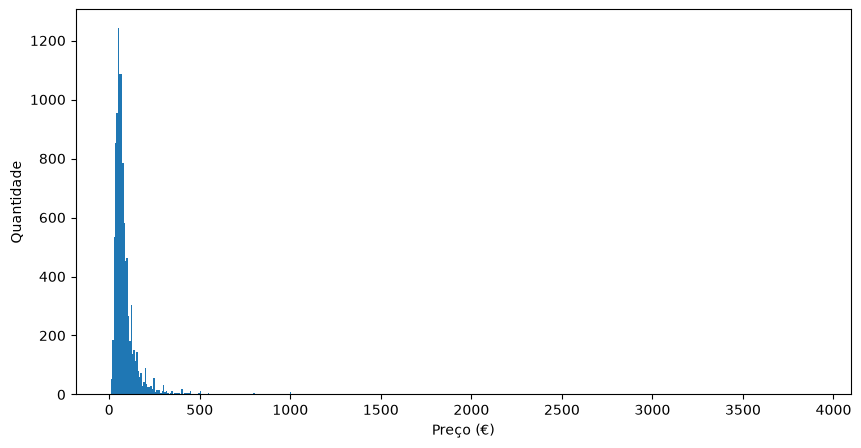

Estadia mínima
    Identificador: minimum_nights
    Tipo: Inteiro
    Quantidade mínima de dias que o hóspede deve contratar de estadia.
    Vazios: 0 de 12044 (0.00%)
    Intervalo numérico: [1, 1125]
    Média: 4.0848555297243445
    Mediana: 2.0
    Desvio padrão: 34.046935670996234
    Percentil 05%: 1.0
    Percentil 25%: 1.0
    Percentil 50%: 2.0
    Percentil 75%: 2.0
    Percentil 95%: 5.0


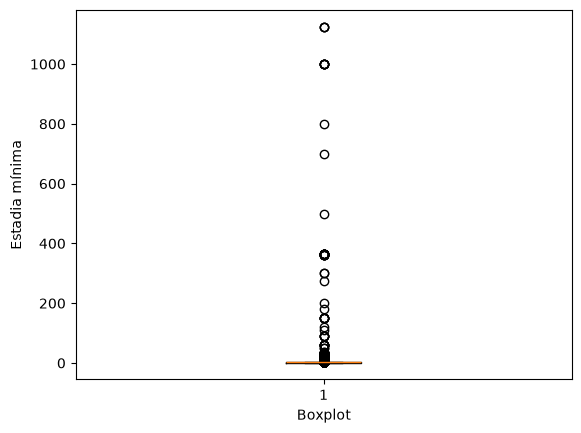

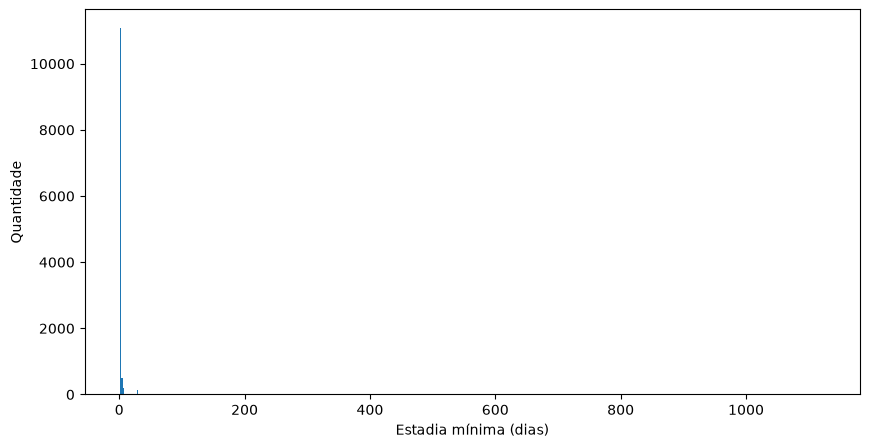

Quantidade de avaliações
    Identificador: number_of_reviews
    Tipo: Inteiro
    Quantidade de avaliações que este anúncio recebeu por meio da plataforma Airbnb.
    Vazios: 0 de 12044 (0.00%)
    Intervalo numérico: [0, 976]
    Média: 76.43839256061109
    Mediana: 36.0
    Desvio padrão: 103.78154024166896
    Percentil 05%: 0.0
    Percentil 25%: 7.0
    Percentil 50%: 36.0
    Percentil 75%: 105.0
    Percentil 95%: 286.85000000000036


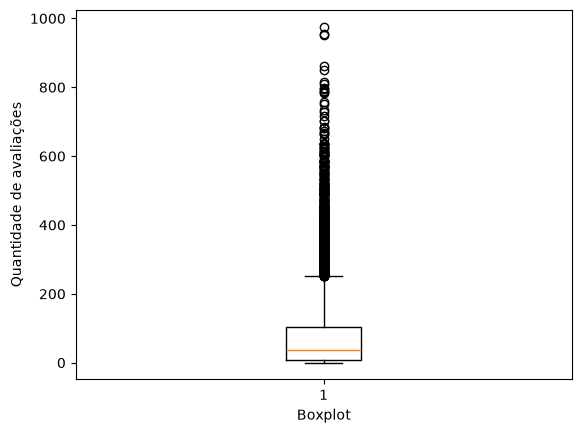

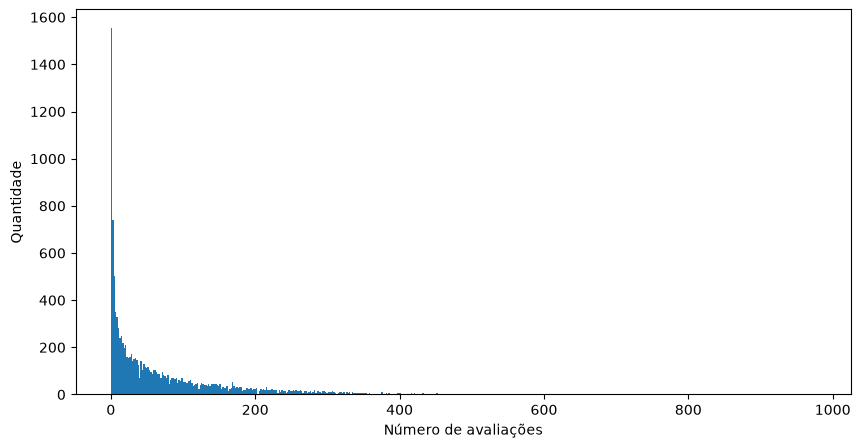

Data da última avaliação
    Identificador: last_review
    Tipo: Data (dia, mês, e ano)
    Data em que a avaliação mais recente deste anúncio foi realizada por meio da plataforma Airbnb.
    Vazios: 1073 de 10971 (9.78%)
    Intervalo numérico: [2013-01-02, 2024-12-14]

Média de avaliações por mês
    Identificador: reviews_per_month
    Tipo: Inteiro
    Quantidade média de avaliações que este anúncio recebeu por mês por meio da plataforma Airbnb.
    Vazios: 1073 de 10971 (9.78%)
    Intervalo numérico: [0.01, 16.43]
    Média: 1.616888159693738
    Mediana: 1.09
    Desvio padrão: 1.5990049823613444
    Percentil 05%: 0.05
    Percentil 25%: 0.33
    Percentil 50%: 1.09
    Percentil 75%: 2.48
    Percentil 95%: 4.89


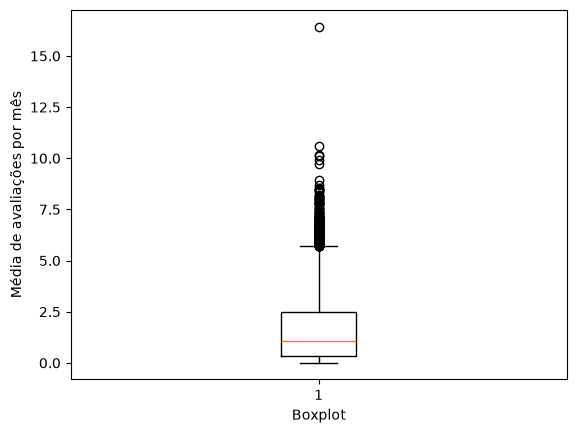

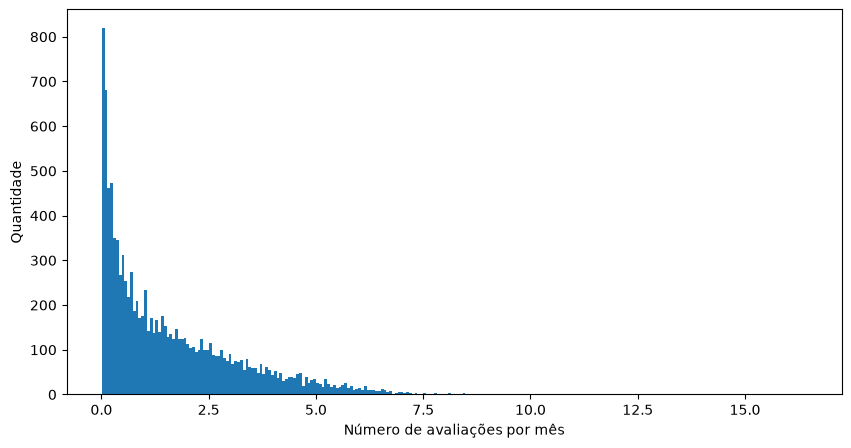

Quantidade de anúncios do anunciante
    Identificador: calculated_host_listings_count
    Tipo: Inteiro
    Quantidade de anúncios que este anunciante realizou na grande região de escopo deste dataset.
    Vazios: 0 de 12044 (0.00%)
    Intervalo numérico: [1, 334]
    Média: 18.3867485885088
    Mediana: 5.0
    Desvio padrão: 43.29776416538993
    Percentil 05%: 1.0
    Percentil 25%: 2.0
    Percentil 50%: 5.0
    Percentil 75%: 13.0
    Percentil 95%: 92.0


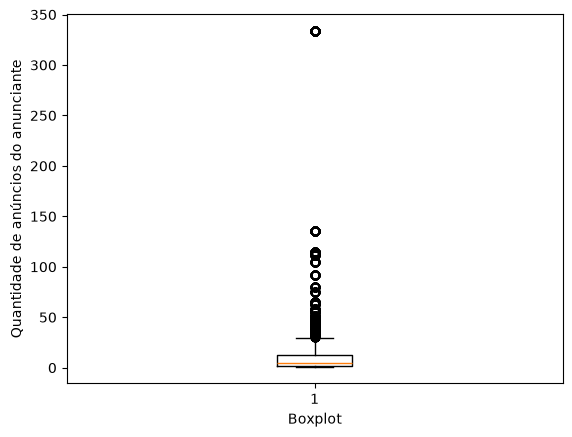

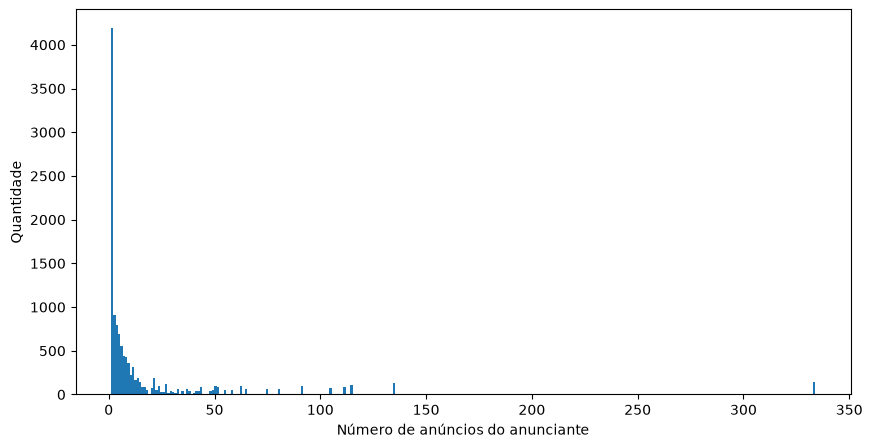

Quantidade de dias disponíveis
    Identificador: availability_365
    Tipo: Inteiro
    Quantidade de dias nos próximos 365 dias em que este anúncio estará disponível para locação.
    Vazios: 0 de 12044 (0.00%)
    Intervalo numérico: [0, 365]
    Média: 234.66722019262704
    Mediana: 286.0
    Desvio padrão: 129.32772094698745
    Percentil 05%: 0.0
    Percentil 25%: 137.0
    Percentil 50%: 286.0
    Percentil 75%: 346.0
    Percentil 95%: 364.0


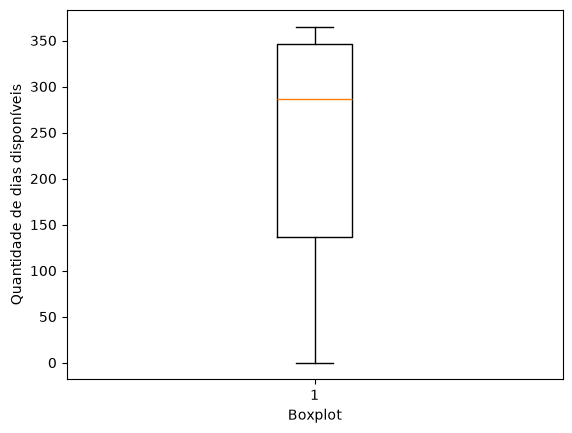

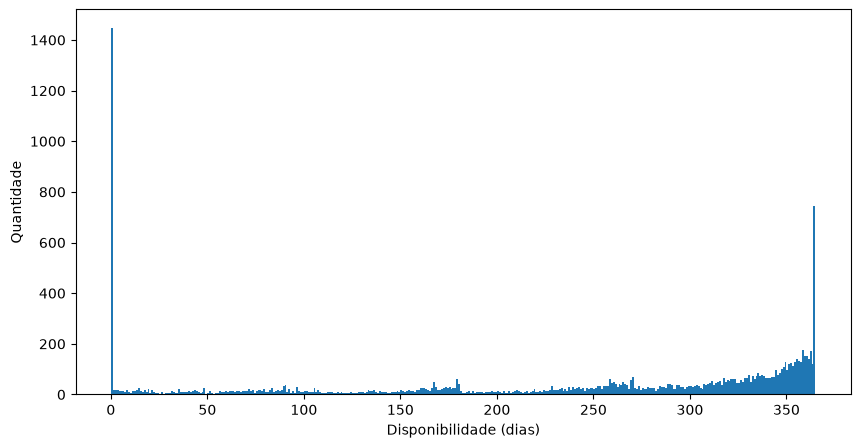

Licença
    Identificador: license
    Tipo: Textual
    Licença de Alojamento Local (AL) obtida para operar a locação do imóvel deste anúncio.
    Vazios: 670 de 11374 (5.89%)



In [387]:
border_line(6)
print("Colunas")
border_line(6)
print()

column_description(
    name="ID do anúncio",
    series=df.id,
    type_description="Textual (sequência de dígitos)",
    description="Identificador interno dado pelo Airbnb para esta entrada.",
    column_type="other",
)
# Creio ser irrelevante.
print()

column_description(
    name="Nome do anúncio",
    series=df.name,
    type_description="Textual",
    description="Nome dado pelos anunciantes a este anúncio.",
    column_type="other",
)
# Creio ser irrelevante.
print()

column_description(
    name="ID do anunciante",
    series=df.host_id,
    type_description="Textual (sequência de dígitos)",
    description="Identificador interno dado pelo Airbnb para a conta do anunciante que registrou esta entrada.",
    column_type="other",
)
# Creio ser irrelevante.
print()

column_description(
    name="Nome do anunciante",
    series=df.host_name,
    type_description="Textual",
    description="Nome do anunciante que registrou esta entrada. Mesmo quando há mais de uma pessoa, eles são responsáveis pela mesma conta no Airbnb.",
    column_type="other",
)
# Creio ser irrelevante.
print()

column_description(
    name="Município do imóvel",
    series=df.neighbourhood_group,
    type_description="Categórico, não ordenado",
    description="Município em que o imóvel anunciado está localizado. Obtido por meio da localização geográfica.",
    column_type="categorical",
)
# Quais municípios serão mais baratos?
print()

column_description(
    name="Freguesia do imóvel",
    series=df.neighbourhood,
    type_description="Categórico, não ordenado",
    description="Freguesia em que o imóvel anunciado está localizado. Está dentro de apenas um município.",
    column_type="categorical",
)
# Quais freguesias serão mais baratas?
print()

column_description(
    name="Latitude do imóvel",
    series=df.latitude,
    type_description="Real",
    description="Latitude da localização do imóvel anunciado conforme o World Geodetic System (WGS84).",
    column_type="other",
)
# Creio ser menos relevante do que a freguesia calculada.
print()

column_description(
    name="Longitude do imóvel",
    series=df.longitude,
    type_description="Real",
    description="Longitude da localização do imóvel anunciado conforme o World Geodetic System (WGS84).",
    column_type="other",
)
# Creio ser menos relevante do que a freguesia calculada.
print()

column_description(
    name="Tipo de locação",
    series=df.room_type,
    type_description="Categórico, não ordenado",
    description="Tipo da locação sendo anunciada. Especifica quais áreas do imóvel o inquilino poderá acessar.",
    column_type="categorical",
)
# Um imóvel menor (quarto) será mais barato?
print()

column_description(
    name="Preço de locação",
    series=df.price,
    type_description="Real",
    description="Preço diário de locação deste anúncio em euros.",
    column_type="numerical",
)
print()
generate_histogram(series=df.price, label="Preço (€)", bins=500)

column_description(
    name="Estadia mínima",
    series=df.minimum_nights,
    type_description="Inteiro",
    description="Quantidade mínima de dias que o hóspede deve contratar de estadia.",
    column_type="numerical",
)
# Um anúncio com estadia longa será mais barato?
print()
generate_histogram(series=df.minimum_nights, label="Estadia mínima (dias)", bins=500)

column_description(
    name="Quantidade de avaliações",
    series=df.number_of_reviews,
    type_description="Inteiro",
    description="Quantidade de avaliações que este anúncio recebeu por meio da plataforma Airbnb.",
    column_type="numerical",
)
# Um anúncio muito avaliado será mais barato?
print()
generate_histogram(series=df.number_of_reviews, label="Número de avaliações", bins=500)

column_description(
    name="Data da última avaliação",
    series=df.last_review,
    type_description="Data (dia, mês, e ano)",
    description="Data em que a avaliação mais recente deste anúncio foi realizada por meio da plataforma Airbnb.",
    column_type="date",
)
# Creio não ter muita relevância.
print()

column_description(
    name="Média de avaliações por mês",
    series=df.reviews_per_month,
    type_description="Inteiro",
    description="Quantidade média de avaliações que este anúncio recebeu por mês por meio da plataforma Airbnb.",
    column_type="numerical",
)
# Um anúncio com muitas avaliações será mais barato?
print()
generate_histogram(
    series=df.reviews_per_month,
    label="Número de avaliações por mês",
    bins=250,
)

column_description(
    name="Quantidade de anúncios do anunciante",
    series=df.calculated_host_listings_count,
    type_description="Inteiro",
    description="Quantidade de anúncios que este anunciante realizou na grande região de escopo deste dataset.",
    column_type="numerical",
)
# Um anunciante que publica muitos anúncios será mais barato?
print()
generate_histogram(
    series=df.calculated_host_listings_count,
    label="Número de anúncios do anunciante",
    bins=300,
)

column_description(
    name="Quantidade de dias disponíveis",
    series=df.availability_365,
    type_description="Inteiro",
    description="Quantidade de dias nos próximos 365 dias em que este anúncio estará disponível para locação.",
    column_type="numerical",
)
# Um imóvel com disponibilidade alta será mais barato?
print()
generate_histogram(
    series=df.availability_365,
    label="Disponibilidade (dias)",
    bins=365,
)

column_description(
    name="Licença",
    series=df.license,
    type_description="Textual",
    description="Licença de Alojamento Local (AL) obtida para operar a locação do imóvel deste anúncio.",
    column_type="other",
)
# Um imóvel sem licença registrada ou isento de licença será mais barato?
print()

In [388]:
def describe_columns(
    data_frame=pd.DataFrame,
    bins=(
        100,
        3,
        100,
        100,
        35,
        365,
    ),
):
    border_line(6)
    print("Colunas")
    border_line(6)
    print()

    column_description(
        name="ID do anúncio",
        series=data_frame.id,
        type_description="Textual (sequência de dígitos)",
        description="Identificador interno dado pelo Airbnb para esta entrada.",
        column_type="other",
    )
    # Creio ser irrelevante.
    print()

    column_description(
        name="Nome do anúncio",
        series=data_frame.name,
        type_description="Textual",
        description="Nome dado pelos anunciantes a este anúncio.",
        column_type="other",
    )
    # Creio ser irrelevante.
    print()

    column_description(
        name="ID do anunciante",
        series=data_frame.host_id,
        type_description="Textual (sequência de dígitos)",
        description="Identificador interno dado pelo Airbnb para a conta do anunciante que registrou esta entrada.",
        column_type="other",
    )
    # Creio ser irrelevante.
    print()

    column_description(
        name="Nome do anunciante",
        series=data_frame.host_name,
        type_description="Textual",
        description="Nome do anunciante que registrou esta entrada. Mesmo quando há mais de uma pessoa, eles são responsáveis pela mesma conta no Airbnb.",
        column_type="other",
    )
    # Creio ser irrelevante.
    print()

    column_description(
        name="Município do imóvel",
        series=data_frame.neighbourhood_group,
        type_description="Categórico, não ordenado",
        description="Município em que o imóvel anunciado está localizado. Obtido por meio da localização geográfica.",
        column_type="categorical",
    )
    # Quais municípios serão mais baratos?
    print()
    generate_bar_graph(
        series=data_frame.neighbourhood_group,
        label="Município do imóvel",
    )

    column_description(
        name="Freguesia do imóvel",
        series=data_frame.neighbourhood,
        type_description="Categórico, não ordenado",
        description="Freguesia em que o imóvel anunciado está localizado. Está dentro de apenas um município.",
        column_type="categorical",
    )
    # Quais freguesias serão mais baratas?
    print()
    generate_pie_graph_with_others(
        series=data_frame.neighbourhood, label="Freguesia do imóvel"
    )

    column_description(
        name="Latitude do imóvel",
        series=data_frame.latitude,
        type_description="Real",
        description="Latitude da localização do imóvel anunciado conforme o World Geodetic System (WGS84).",
        column_type="other",
    )
    # Creio ser menos relevante do que a freguesia calculada.
    print()

    column_description(
        name="Longitude do imóvel",
        series=data_frame.longitude,
        type_description="Real",
        description="Longitude da localização do imóvel anunciado conforme o World Geodetic System (WGS84).",
        column_type="other",
    )
    # Creio ser menos relevante do que a freguesia calculada.
    print()

    column_description(
        name="Tipo de locação",
        series=data_frame.room_type,
        type_description="Categórico, não ordenado",
        description="Tipo da locação sendo anunciada. Especifica quais áreas do imóvel o inquilino poderá acessar.",
        column_type="categorical",
    )
    # Um imóvel menor (quarto) será mais barato?
    print()
    generate_bar_graph(series=data_frame.room_type, label="Tipo de locação")

    column_description(
        name="Preço de locação",
        series=data_frame.price,
        type_description="Real",
        description="Preço diário de locação deste anúncio em euros.",
        column_type="numerical",
    )
    print()
    generate_histogram(series=data_frame.price, label="Preço (€)", bins=bins[0])

    column_description(
        name="Estadia mínima",
        series=data_frame.minimum_nights,
        type_description="Inteiro",
        description="Quantidade mínima de dias que o hóspede deve contratar de estadia.",
        column_type="numerical",
    )
    # Um anúncio com estadia longa será mais barato?
    print()
    generate_histogram(
        series=data_frame.minimum_nights, label="Estadia mínima (dias)", bins=bins[1]
    )

    column_description(
        name="Quantidade de avaliações",
        series=data_frame.number_of_reviews,
        type_description="Inteiro",
        description="Quantidade de avaliações que este anúncio recebeu por meio da plataforma Airbnb.",
        column_type="numerical",
    )
    # Um anúncio muito avaliado será mais barato?
    print()
    generate_histogram(
        series=data_frame.number_of_reviews, label="Número de avaliações", bins=bins[2]
    )

    column_description(
        name="Data da última avaliação",
        series=data_frame.last_review,
        type_description="Categórico, não ordenado",
        description="Data em que a avaliação mais recente deste anúncio foi realizada por meio da plataforma Airbnb.",
        column_type="categorical",
    )
    # Creio não ter muita relevância.
    print()
    generate_bar_graph(series=data_frame.last_review, label="Data da última avaliação")

    column_description(
        name="Média de avaliações por mês",
        series=data_frame.reviews_per_month,
        type_description="Inteiro",
        description="Quantidade média de avaliações que este anúncio recebeu por mês por meio da plataforma Airbnb.",
        column_type="numerical",
    )
    # Um anúncio com muitas avaliações será mais barato?
    print()
    generate_histogram(
        series=data_frame.reviews_per_month,
        label="Número de avaliações por mês",
        bins=bins[3],
    )

    column_description(
        name="Quantidade de anúncios do anunciante",
        series=data_frame.calculated_host_listings_count,
        type_description="Inteiro",
        description="Quantidade de anúncios que este anunciante realizou na grande região de escopo deste dataset.",
        column_type="numerical",
    )
    # Um anunciante que publica muitos anúncios será mais barato?
    print()
    generate_histogram(
        series=data_frame.calculated_host_listings_count,
        label="Número de anúncios do anunciante",
        bins=bins[4],
    )

    column_description(
        name="Quantidade de dias disponíveis",
        series=data_frame.availability_365,
        type_description="Inteiro",
        description="Quantidade de dias nos próximos 365 dias em que este anúncio estará disponível para locação.",
        column_type="numerical",
    )
    # Um imóvel com disponibilidade alta será mais barato?
    print()
    generate_histogram(
        series=data_frame.availability_365, label="Disponibilidade (dias)", bins=bins[5]
    )

    column_description(
        name="Licença",
        series=data_frame.license,
        type_description="Categórico, não ordenado",
        description="Licença de Alojamento Local (AL) obtida para operar a locação do imóvel deste anúncio.",
        column_type="categorical",
    )
    # Um imóvel sem licença registrada ou isento de licença será mais barato?
    print()


In [389]:
total_amount_before_treatment = df.id.size

print(f"{open_bold}Remoção de entradas sem atributo de interesse{close_bold}")

empty_amount_of_price = df.price.isna().sum()
not_empty_amount_of_price = total_amount_before_treatment - empty_amount_of_price
print(
    f"""O objetivo do modelo é estimar o {open_bold}preço de hospedagem por dia{close_bold} (em euros).
Logo, não faz sentido completar os dados faltantes na coluna {open_bold}price{close_bold}.
Assim, as {empty_amount_of_price} entradas vazias foram eliminadas, restando {open_bold}{not_empty_amount_of_price}{close_bold} entradas ({(empty_amount_of_price / total_amount_before_treatment):.2%} / {(not_empty_amount_of_price / total_amount_before_treatment):.2%}).""",
)
df2 = df.dropna(subset=["price"])


Remoção de entradas sem atributo de interesse
O objetivo do modelo é estimar o preço de hospedagem por dia (em euros).
Logo, não faz sentido completar os dados faltantes na coluna price.
Assim, as 1593 entradas vazias foram eliminadas, restando 10451 entradas (13.23% / 86.77%).


In [390]:
print(f"{open_bold}Remoção de duplicatas{close_bold}")

print("São consideradas entradas duplicadas aquelas:")
print(
    textwrap.indent(
        'que compartilham Nome, ID do anunciante, Licença;\ne que sejam de tipo "Entire home/apt",\npois quartos individuais podem ser anúncios separados de um mesmo apartamento ou casa.',
        indentation,
    )
)
print(
    f"\nPara as duplicatas, será mantida a que tenha a maior quantidade de {open_bold}colunas preenchidas{close_bold}.\nEm caso de empate, considerar-se-á aquela com maior quantidade de {open_bold}avaliações{close_bold}.\n"
)


def print_statistics_about_removal(total_amount: int, remaining_amount: int):
    removed_amount = total_amount - remaining_amount
    print(
        f"Eliminadas {total_amount - remaining_amount} entradas de {total_amount} ({(removed_amount / total_amount):.2%} / {(remaining_amount / total_amount):.2%})."
    )


total_amount = df2.id.size

entire_home_mask = df2["room_type"].eq("Entire home/apt")
has_license_mask = df2["license"].notna()
duplicated_mask = (
    entire_home_mask
    & has_license_mask
    & df2.duplicated(subset=["host_id", "name", "license"], keep=False)
)

df2[duplicated_mask].sort_values(["host_id", "name", "license"])

df_selected = df2[duplicated_mask].copy()
df_not_selected = df2[~duplicated_mask].copy()

df_selected["filled_columns"] = df_selected.notna().sum(axis=1)
df_selected = df_selected.sort_values(
    ["host_id", "name", "license", "filled_columns", "number_of_reviews"],
    ascending=[True, True, True, False, False],
).drop_duplicates(subset=["host_id", "name", "license"], keep="first")

df3 = pd.concat([df_not_selected, df_selected], ignore_index=True)
df3 = df3.drop(columns="filled_columns")

remaining_amount = df3.id.size
print_statistics_about_removal(
    total_amount=total_amount, remaining_amount=remaining_amount
)
print()

print(f"{open_bold}Total inicial{close_bold}.", end=" ")
print_statistics_about_removal(
    total_amount=total_amount_before_treatment, remaining_amount=remaining_amount
)


Remoção de duplicatas
São consideradas entradas duplicadas aquelas:
    que compartilham Nome, ID do anunciante, Licença;
    e que sejam de tipo "Entire home/apt",
    pois quartos individuais podem ser anúncios separados de um mesmo apartamento ou casa.

Para as duplicatas, será mantida a que tenha a maior quantidade de colunas preenchidas.
Em caso de empate, considerar-se-á aquela com maior quantidade de avaliações.

Eliminadas 46 entradas de 10451 (0.44% / 99.56%).

Total inicial. Eliminadas 1639 entradas de 12044 (13.61% / 86.39%).


In [391]:
print(f"{open_bold}Detecção de outliers{close_bold}")

print(
    f"Para os atributos numéricos, usamos o {open_bold}Intervalo Interquartil (IQR){close_bold}.\nAs entradas com valores fora do intervalo foram substituídas pelos limites calculados.\n"
)


def print_statistics_about_modifying(total_amount: int, modified_amount: int):
    not_modified_amount = total_amount - modified_amount
    print(
        f"Modificadas {modified_amount} entradas de {total_amount} ({(modified_amount / total_amount):.2%} / {(not_modified_amount / total_amount):.2%})."
    )


def treat_outliers_through_iqr(
    data_frame: pd.DataFrame,
    column_name: str,
    attribute_name: str,
):
    first_quartile = data_frame[column_name].quantile(0.25)
    third_quartile = data_frame[column_name].quantile(0.75)
    iqr = third_quartile - first_quartile
    lower = first_quartile - 1.5 * iqr
    upper = third_quartile + 1.5 * iqr
    outliers = (data_frame[column_name] < lower) | (data_frame[column_name] > upper)
    outliers_amount = outliers.sum()
    data_frame[column_name] = data_frame[column_name].clip(
        lower=lower,
        upper=upper,
    )
    print(f"Atributo: {open_bold}{attribute_name}{close_bold}.", end=" ")
    print_statistics_about_modifying(
        total_amount=total_amount, modified_amount=outliers_amount
    )
    return data_frame


df4 = df3.copy()

df4 = treat_outliers_through_iqr(
    data_frame=df4, column_name="price", attribute_name="Preço de locação"
)
df4 = treat_outliers_through_iqr(
    data_frame=df4, column_name="minimum_nights", attribute_name="Estadia mínima"
)
df4 = treat_outliers_through_iqr(
    data_frame=df4,
    column_name="number_of_reviews",
    attribute_name="Quantidade de avaliações",
)
df4 = treat_outliers_through_iqr(
    data_frame=df4,
    column_name="reviews_per_month",
    attribute_name="Média de avaliações por mês",
)
df4 = treat_outliers_through_iqr(
    data_frame=df4,
    column_name="calculated_host_listings_count",
    attribute_name="Quantidade de anúncios do anunciante",
)
print()


Detecção de outliers
Para os atributos numéricos, usamos o Intervalo Interquartil (IQR).
As entradas com valores fora do intervalo foram substituídas pelos limites calculados.

Atributo: Preço de locação. Modificadas 784 entradas de 10451 (7.50% / 92.50%).
Atributo: Estadia mínima. Modificadas 722 entradas de 10451 (6.91% / 93.09%).
Atributo: Quantidade de avaliações. Modificadas 636 entradas de 10451 (6.09% / 93.91%).
Atributo: Média de avaliações por mês. Modificadas 188 entradas de 10451 (1.80% / 98.20%).
Atributo: Quantidade de anúncios do anunciante. Modificadas 1552 entradas de 10451 (14.85% / 85.15%).



In [392]:
print(f"{open_bold}Preenchimento de valores faltantes{close_bold}\n")

df5 = df4.copy()

print(
    f"Atributo: {open_bold}Média de avaliações por mês{close_bold}.\n{indentation}Todas as entradas faltantes são de anúncios sem avaliações. Basta substituir por {open_bold}0{close_bold}."
)
print(indentation, end="")
print_statistics_about_modifying(
    total_amount=total_amount, modified_amount=df.reviews_per_month.isna().sum()
)
df5["reviews_per_month"] = df5["reviews_per_month"].fillna(0)


Preenchimento de valores faltantes

Atributo: Média de avaliações por mês.
    Todas as entradas faltantes são de anúncios sem avaliações. Basta substituir por 0.
    Modificadas 1073 entradas de 10451 (10.27% / 89.73%).


In [393]:
print(f"{open_bold}Transformação de atributos diversos em categóricos{close_bold}\n")

df6 = df5.copy()

print(f"Atributo: {open_bold}Data da última avaliação{close_bold}.")
print(
    textwrap.indent(
        f'Podem ser substituídas apenas pelo {open_bold}ano{close_bold} (2013 - 2024).\nAquelas não preenchidas entram em uma categoria "no_reviews".',
        indentation,
    )
)
df6["last_review"] = (
    df6["last_review"]
    .dt.year.astype("Int64")
    .astype("string")
    .fillna("no_reviews")
    .astype("category")
)

print(f"\nAtributo: {open_bold}Licença{close_bold}.")
print(
    textwrap.indent(
        f'Podem ser substituídas pelo {open_bold}tipo de licença{close_bold}.\n"no_license", "al", "ter", "exempt" e "others".',
        indentation,
    )
)
license = df6["license"].astype("string").str.strip()

df6["license"] = np.select(
    [
        license.isna() | license.eq(""),
        # AL:
        # - contains AL
        # - or it has only numbers
        license.str.contains(r"\bAL\b", case=False, na=False)
        | license.str.fullmatch(r"\d+", na=False),
        # TER:
        # - contains TER, RNET, RNT or rural
        license.str.contains(
            r"TER|RNET|RNT|rural",
            case=False,
            na=False,
        ),
        # Exempt
        license.str.fullmatch(
            r"exempt",
            case=False,
            na=False,
        ),
    ],
    [
        "no_license",
        "al",
        "ter",
        "exempt",
    ],
    default="others",
)
df6["license"] = df6["license"].astype("category")


Transformação de atributos diversos em categóricos

Atributo: Data da última avaliação.
    Podem ser substituídas apenas pelo ano (2013 - 2024).
    Aquelas não preenchidas entram em uma categoria "no_reviews".



Atributo: Licença.
    Podem ser substituídas pelo tipo de licença.
    "no_license", "al", "ter", "exempt" e "others".


=-=-=-=
Colunas
=-=-=-=

ID do anúncio
    Identificador: id
    Tipo: Textual (sequência de dígitos)
    Identificador interno dado pelo Airbnb para esta entrada.
    Vazios: 0 de 10405 (0.00%)

Nome do anúncio
    Identificador: name
    Tipo: Textual
    Nome dado pelos anunciantes a este anúncio.
    Vazios: 0 de 10405 (0.00%)

ID do anunciante
    Identificador: host_id
    Tipo: Textual (sequência de dígitos)
    Identificador interno dado pelo Airbnb para a conta do anunciante que registrou esta entrada.
    Vazios: 0 de 10405 (0.00%)

Nome do anunciante
    Identificador: host_name
    Tipo: Textual
    Nome do anunciante que registrou esta entrada. Mesmo quando há mais de uma pessoa, eles são responsáveis pela mesma conta no Airbnb.
    Vazios: 0 de 10405 (0.00%)

Município do imóvel
    Identificador: neighbourhood_group
    Tipo: Categórico, não ordenado
    Município em que o imóvel anunciado está localizado. Obtido por meio da localização geográfica.
    Vazios: 0 de 10405

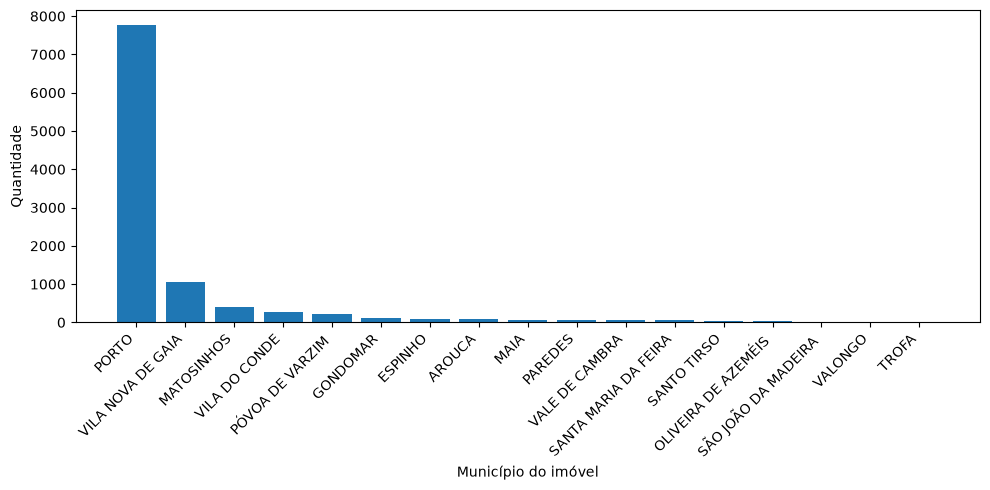

Freguesia do imóvel
    Identificador: neighbourhood
    Tipo: Categórico, não ordenado
    Freguesia em que o imóvel anunciado está localizado. Está dentro de apenas um município.
    Vazios: 0 de 10405 (0.00%)
    Valores possíveis: 155 ['AVer-o-Mar, Amorim e Terroso', 'Agrela', 'Aguiar de Sousa', 'Aguçadoura e Navais', 'Aldoar, Foz do Douro e Nevogilde', 'Alfena', 'Alvarelhos e Guidões', 'Alvarenga', 'Anta e Guetim', 'Arcozelo', 'Areias, Sequeiró, Lama e Palmeira', 'Argoncilhe', 'Arouca e Burgo', 'Arrifana', 'Arões', 'Aveleda', 'Avintes', 'Azurara', 'Baguim do Monte (Rio Tinto)', 'Bagunte, Ferreiró, Outeiro Maior e Parada', 'Balazar', 'Baltar', 'Bonfim', 'Bougado (São Martinho e Santiago)', 'Cabreiros e Albergaria da Serra', 'Caldas de São Jorge e de Pigeiros', 'Campanhã', 'Campo e Sobrado', 'Canedo, Vale e Vila Maior', 'Canelas', 'Canelas e Espiunca', 'Canidelo', 'Carregosa', 'Carreira e Refojos de Riba de Ave', 'Castêlo da Maia', 'Cedofeita, Ildefonso, Sé, Miragaia, Nicolau, Vitór

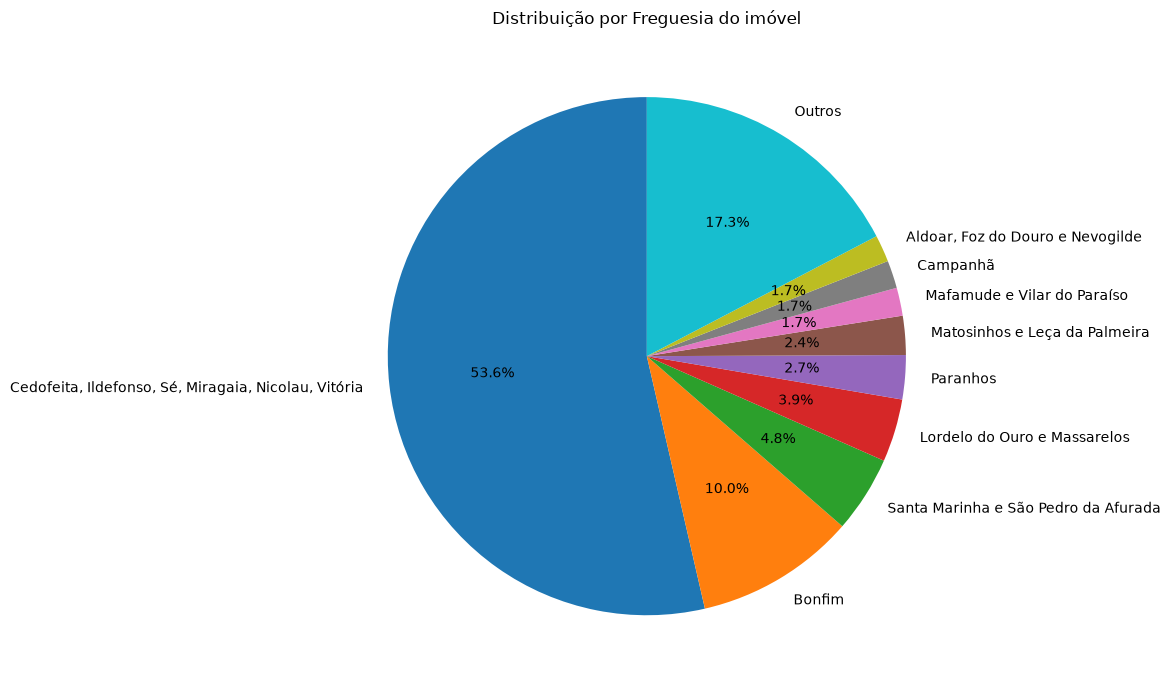

Latitude do imóvel
    Identificador: latitude
    Tipo: Real
    Latitude da localização do imóvel anunciado conforme o World Geodetic System (WGS84).
    Vazios: 0 de 10405 (0.00%)

Longitude do imóvel
    Identificador: longitude
    Tipo: Real
    Longitude da localização do imóvel anunciado conforme o World Geodetic System (WGS84).
    Vazios: 0 de 10405 (0.00%)

Tipo de locação
    Identificador: room_type
    Tipo: Categórico, não ordenado
    Tipo da locação sendo anunciada. Especifica quais áreas do imóvel o inquilino poderá acessar.
    Vazios: 0 de 10405 (0.00%)
    Valores possíveis: 4 ['Entire home/apt', 'Hotel room', 'Private room', 'Shared room']



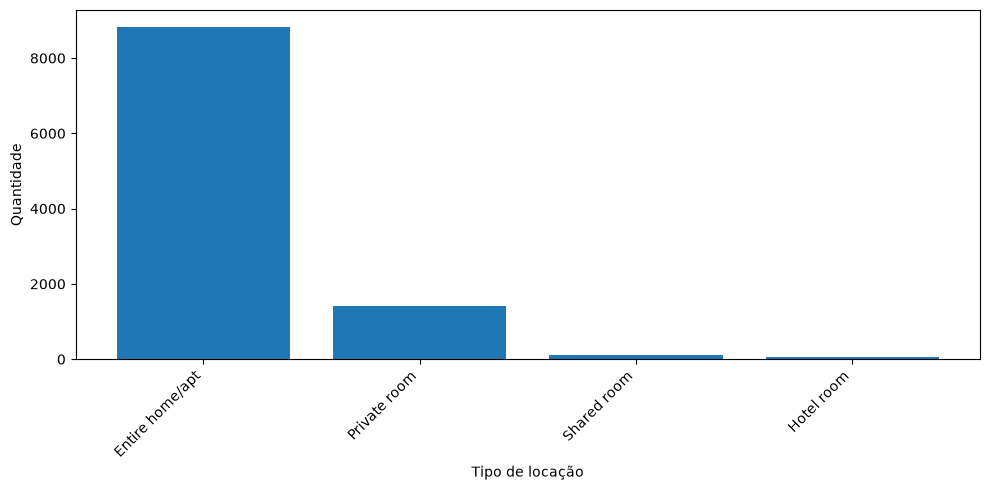

Preço de locação
    Identificador: price
    Tipo: Real
    Preço diário de locação deste anúncio em euros.
    Vazios: 0 de 10405 (0.00%)
    Intervalo numérico: [9.0, 165.5]
    Média: 76.27928880345988
    Mediana: 65.0
    Desvio padrão: 39.292988011062235
    Percentil 05%: 30.0
    Percentil 25%: 48.0
    Percentil 50%: 65.0
    Percentil 75%: 95.0
    Percentil 95%: 165.5


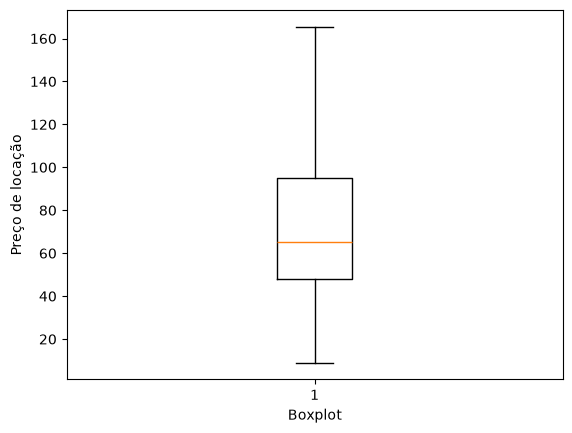

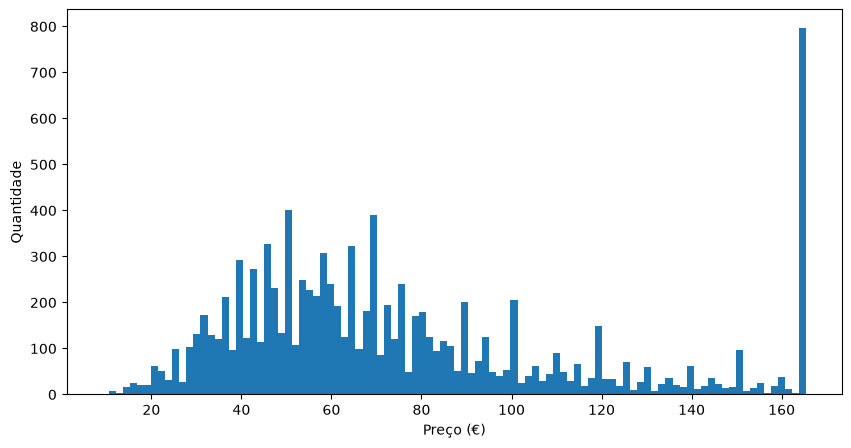

Estadia mínima
    Identificador: minimum_nights
    Tipo: Inteiro
    Quantidade mínima de dias que o hóspede deve contratar de estadia.
    Vazios: 0 de 10405 (0.00%)
    Intervalo numérico: [1.0, 3.5]
    Média: 1.8890917827967324
    Mediana: 2.0
    Desvio padrão: 0.8113899815546088
    Percentil 05%: 1.0
    Percentil 25%: 1.0
    Percentil 50%: 2.0
    Percentil 75%: 2.0
    Percentil 95%: 3.5


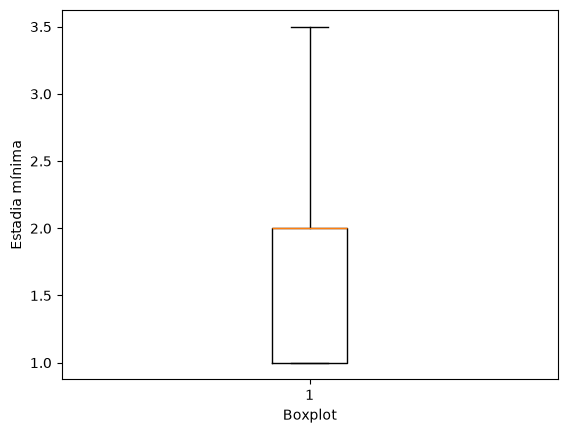

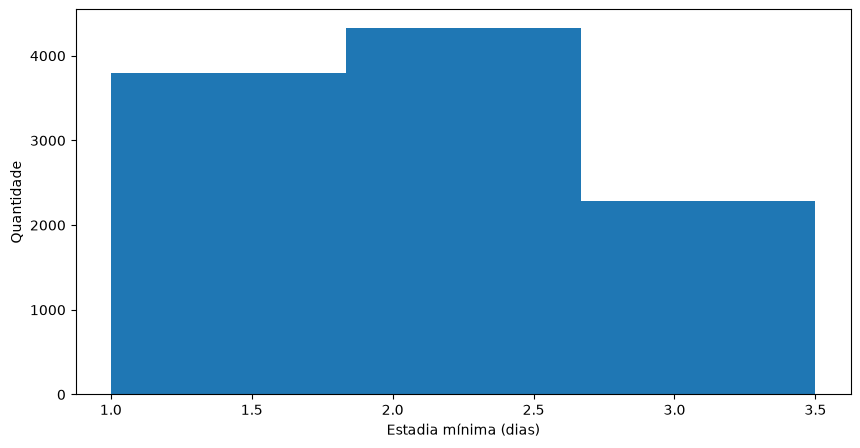

Quantidade de avaliações
    Identificador: number_of_reviews
    Tipo: Inteiro
    Quantidade de avaliações que este anúncio recebeu por meio da plataforma Airbnb.
    Vazios: 0 de 10405 (0.00%)
    Intervalo numérico: [0, 280]
    Média: 76.9611725132148
    Mediana: 45.0
    Desvio padrão: 84.16810516071506
    Percentil 05%: 0.0
    Percentil 25%: 10.0
    Percentil 50%: 45.0
    Percentil 75%: 118.0
    Percentil 95%: 280.0


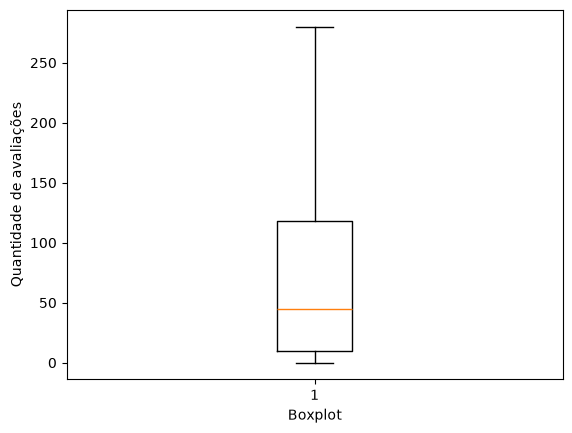

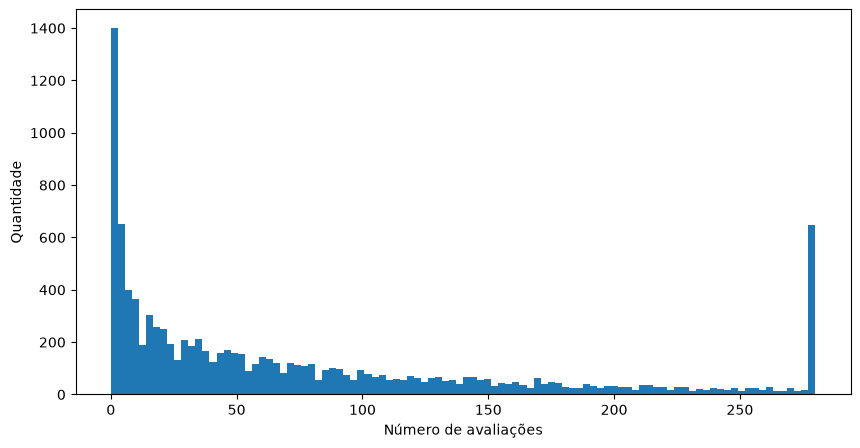

Data da última avaliação
    Identificador: last_review
    Tipo: Categórico, não ordenado
    Data em que a avaliação mais recente deste anúncio foi realizada por meio da plataforma Airbnb.
    Vazios: 0 de 10405 (0.00%)
    Valores possíveis: 13 ['2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', 'no_reviews']



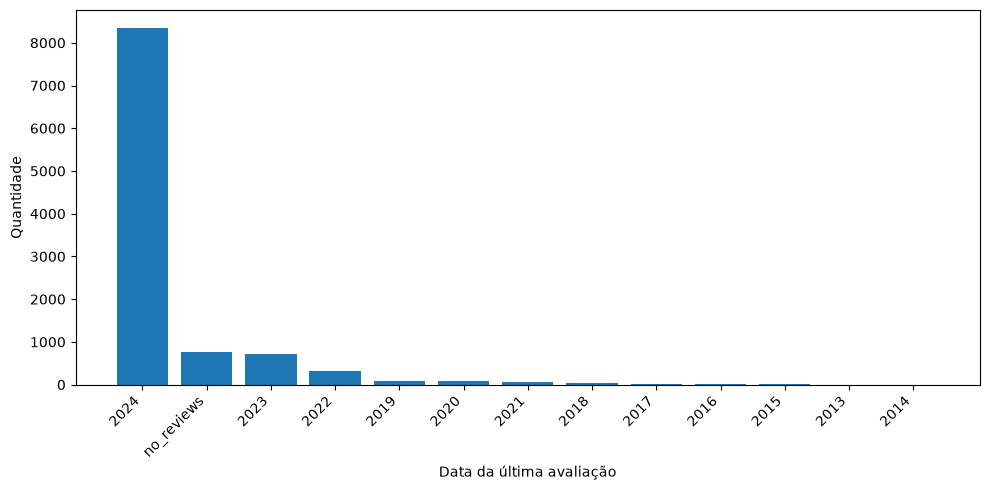

Média de avaliações por mês
    Identificador: reviews_per_month
    Tipo: Inteiro
    Quantidade média de avaliações que este anúncio recebeu por mês por meio da plataforma Airbnb.
    Vazios: 0 de 10405 (0.00%)
    Intervalo numérico: [0.0, 6.015]
    Média: 1.6169697260932243
    Mediana: 1.12
    Desvio padrão: 1.5742848609695343
    Percentil 05%: 0.0
    Percentil 25%: 0.3
    Percentil 50%: 1.12
    Percentil 75%: 2.54
    Percentil 95%: 4.937999999999993


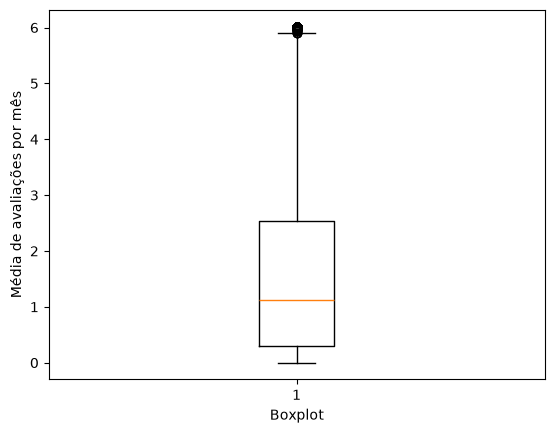

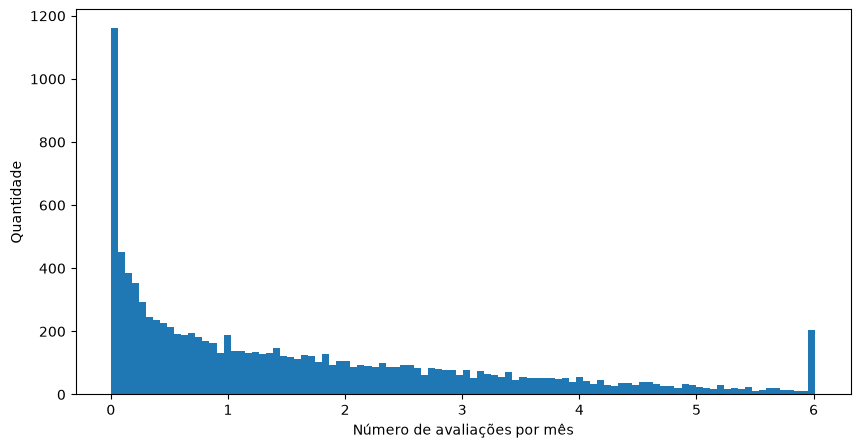

Quantidade de anúncios do anunciante
    Identificador: calculated_host_listings_count
    Tipo: Inteiro
    Quantidade de anúncios que este anunciante realizou na grande região de escopo deste dataset.
    Vazios: 0 de 10405 (0.00%)
    Intervalo numérico: [1.0, 34.5]
    Média: 10.609226333493513
    Mediana: 5.0
    Desvio padrão: 11.881330095237074
    Percentil 05%: 1.0
    Percentil 25%: 2.0
    Percentil 50%: 5.0
    Percentil 75%: 15.0
    Percentil 95%: 34.5


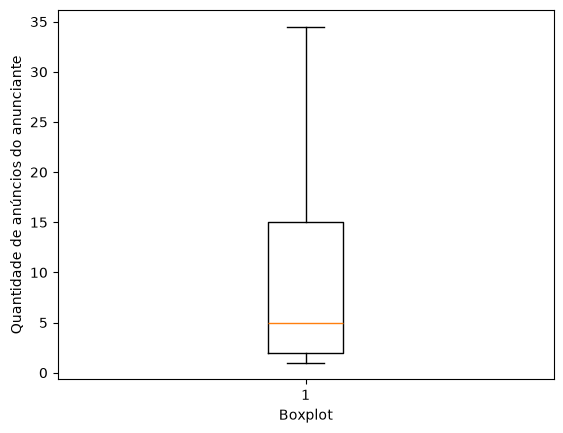

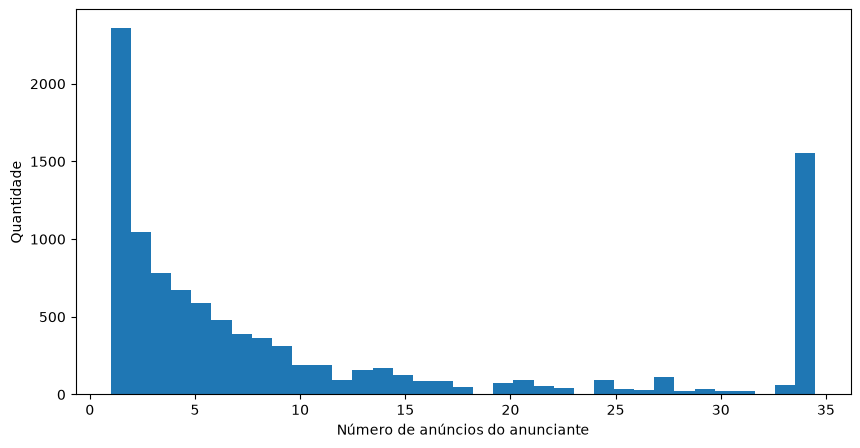

Quantidade de dias disponíveis
    Identificador: availability_365
    Tipo: Inteiro
    Quantidade de dias nos próximos 365 dias em que este anúncio estará disponível para locação.
    Vazios: 0 de 10405 (0.00%)
    Intervalo numérico: [0, 365]
    Média: 262.3772224891879
    Mediana: 306.0
    Desvio padrão: 106.50192205024732
    Percentil 05%: 35.0
    Percentil 25%: 196.0
    Percentil 50%: 306.0
    Percentil 75%: 349.0
    Percentil 95%: 364.0


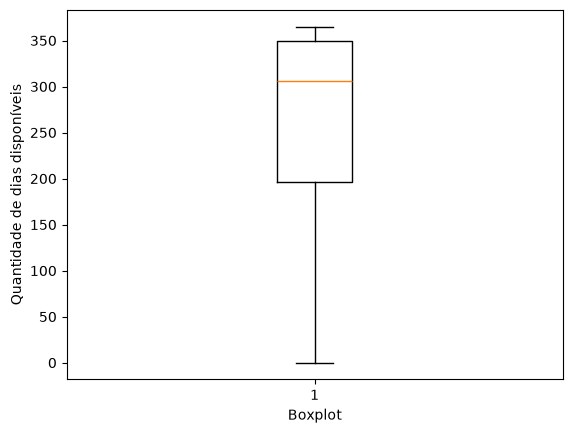

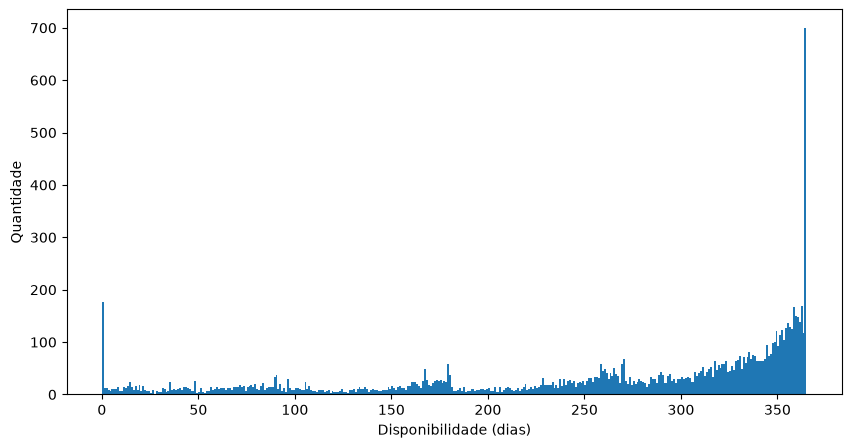

Licença
    Identificador: license
    Tipo: Categórico, não ordenado
    Licença de Alojamento Local (AL) obtida para operar a locação do imóvel deste anúncio.
    Vazios: 0 de 10405 (0.00%)
    Valores possíveis: 5 ['al', 'exempt', 'no_license', 'others', 'ter']



In [394]:
describe_columns(data_frame=df6, bins=(100, 3, 100, 100, 35, 365))
